# Include path

In [1]:
import os
import sys

# Add the '../sources' directory to the Python path using source_dir,
# and add its parent directory as well.
source_dir = os.path.abspath(os.path.join("..", "sources"))
parent_dir = os.path.abspath(os.path.join(source_dir, os.pardir))

for directory in [source_dir, parent_dir]:
    if directory not in sys.path:
        sys.path.insert(0, directory)

print(f"Included '{source_dir}' and its parent directory '{parent_dir}' in sys.path.")



Included '/zhome/2f/7/202918/phc_nzi/sources' and its parent directory '/zhome/2f/7/202918/phc_nzi' in sys.path.


# Define Structure

In [2]:
## Define the materials
from sources.photonic_crystal_maker import Material
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal
from sources.mpb_configurator import MPBSchemeConfigurator
import meep as mp
from sources.photonic_crystal_maker import Lattice, Geometry, PhotonicCrystal
from sources.mpb_configurator import *


n_InP = 3.1

eps = round(n_InP**2,2)
print("Epsilon of InP: ", eps)
InP = Material(epsilon = eps)
air = Material(epsilon = 1)
## Simulation Name: 
name = "simulation_InP"

## Define the lattice

lattice = Lattice(type="TXY")
centers = lattice.get_centers()
k_points = lattice.get_high_symmetry_k_points(True)

## Define the geometry

radius1 = ScriptParam("r1", 0.3)
radius2 = ScriptParam("r2", 0.2)
bulk = Geometry(geom_type=mp.Block, params={"center": mp.Vector3(0,0,0), "size": mp.Vector3(1e20, 1e20, 1e20), "material": InP})
hole1 = Geometry(geom_type=mp.Cylinder, params={"center": centers[0], "radius": radius1, "height": 1e20, "material": air})
hole2 = Geometry(geom_type=mp.Cylinder, params={"center": centers[1], "radius": radius2, "height": 1e20, "material": air})
photonic_crystal = PhotonicCrystal(atoms=[bulk, hole1, hole2], lattice=lattice)

## Define the simulation

configuration_options_opt = dict(
    resolution=64,
    num_bands=8,
    k_points=[mp.Vector3(0, 0, 0)],
    k_point_interpolation_factor=None, 
)
mpb_config_opt = MPBSchemeConfigurator(photonic_crystal, ["te", "tm"], **configuration_options_opt)
script_opt = mpb_config_opt.get_scheme_config(join_newline=True)

configuration_options_single = dict(
    resolution=64,
    num_bands=8,
    k_points=k_points["k_points_values"],
    k_point_interpolation_factor=20, 
)

mpb_config_single = MPBSchemeConfigurator(photonic_crystal, ["te", "tm"], **configuration_options_single)
script_single = mpb_config_single.get_scheme_config(join_newline=True)


Epsilon of InP:  9.61
Found script param: radius with value: r1
Found script param: radius with value: r2
COMMANDS ['(define-param r1 0.3)', '(define-param r2 0.2)']
COMMANDS ['(define-param r1 0.3)', '(define-param r2 0.2)']


## Print Script

In [3]:
# Script used in optimization
print(script_opt)

(set! num-bands 8)
(set! resolution 64)
(set! k-points (list (vector3 0.0 0.0 0.0)))

(define-param r1 0.3)
(define-param r2 0.2)
(set! geometry-lattice (make lattice (size 1 1 no-size) (basis1  (vector3 1.0 0.0 0.0)) (basis2  (vector3 0.5000000000000001 0.8660254037844388 0.0)) ))
(set! geometry (list 
 (make block (center (vector3 0.0 0.0 0.0))
  (size (vector3 1e+20 1e+20 1e+20))
  (material (make dielectric (epsilon 9.61))))
 (make cylinder (center (vector3 0.3333333333333333 0.3333333333333333 0.0))
  (radius r1)
  (height 1e+20)
  (material (make dielectric (epsilon 1))))
 (make cylinder (center (vector3 0.6666666666666666 0.6666666666666666 0.0))
  (radius r2)
  (height 1e+20)
  (material (make dielectric (epsilon 1))))
))


(define (output-nonbloch-efield which-band)
    (get-efield which-band)
    (cvector-field-nonbloch! cur-field)
    (output-field-to-file -1 (string-append (get-filename-prefix)"e."))
)


(define (output-nonbloch-hfield which-band)
    (get-hfield which-band

In [4]:
## script used in single run 
print(script_single)

(set! num-bands 8)
(set! resolution 64)
(set! k-points (list (vector3 0.5 0.0 0.0) (vector3 0.0 0.0 0.0) (vector3 0.3333333333333333 0.3333333333333333 0.0) (vector3 0.5 0.0 0.0)))
(set! k-points (interpolate 20 k-points))
(define-param r1 0.3)
(define-param r2 0.2)
(set! geometry-lattice (make lattice (size 1 1 no-size) (basis1  (vector3 1.0 0.0 0.0)) (basis2  (vector3 0.5000000000000001 0.8660254037844388 0.0)) ))
(set! geometry (list 
 (make block (center (vector3 0.0 0.0 0.0))
  (size (vector3 1e+20 1e+20 1e+20))
  (material (make dielectric (epsilon 9.61))))
 (make cylinder (center (vector3 0.3333333333333333 0.3333333333333333 0.0))
  (radius r1)
  (height 1e+20)
  (material (make dielectric (epsilon 1))))
 (make cylinder (center (vector3 0.6666666666666666 0.6666666666666666 0.0))
  (radius r2)
  (height 1e+20)
  (material (make dielectric (epsilon 1))))
))


(define (output-nonbloch-efield which-band)
    (get-efield which-band)
    (cvector-field-nonbloch! cur-field)
    (outp

# Run Single, unoptimized

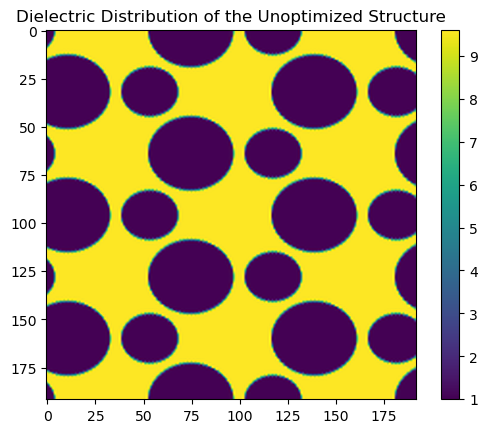

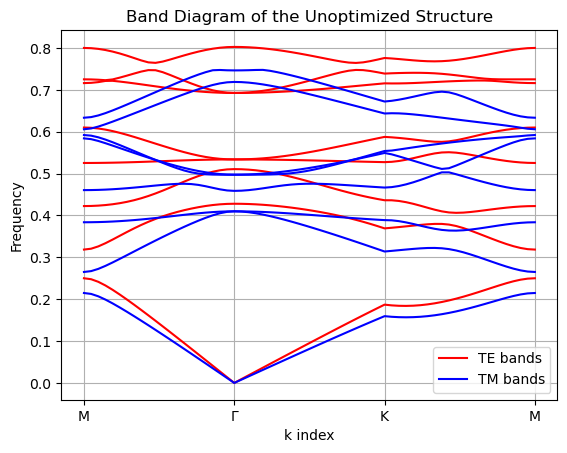

In [5]:
from sources.mpi_differential_evolution import MPIDiffEvoSimulation
from sources.simulation_handler import Simulation
from sources.simulation_handler import SimulationViewer
import matplotlib.pyplot as plt
# Create your Simulation instance.
sim_single = Simulation(simulation_name=name + "_single_unoptimized",
                 script=script_single,
                 log_level = Simulation.WARNING)

sim_single.run_hpc(mpb_command_line_params={"r1":0.20, "r2":0.3})

viewer = SimulationViewer(sim_single)
viewer.plot_epsilon_2d(conversion_options={"rectify": True, "periods": 3})
plt.title("Dielectric Distribution of the Unoptimized Structure")
viewer.show()
viewer.newfig()
viewer.plot_band_diagram("te", colors = "red", k_points_path=k_points)
viewer.plot_band_diagram("tm", colors = "blue", k_points_path=k_points)
plt.title("Band Diagram of the Unoptimized Structure")
viewer.show()

# Optimization

## Run

In [6]:
print(script_opt)

(set! num-bands 8)
(set! resolution 64)
(set! k-points (list (vector3 0.0 0.0 0.0)))

(define-param r1 0.3)
(define-param r2 0.2)
(set! geometry-lattice (make lattice (size 1 1 no-size) (basis1  (vector3 1.0 0.0 0.0)) (basis2  (vector3 0.5000000000000001 0.8660254037844388 0.0)) ))
(set! geometry (list 
 (make block (center (vector3 0.0 0.0 0.0))
  (size (vector3 1e+20 1e+20 1e+20))
  (material (make dielectric (epsilon 9.61))))
 (make cylinder (center (vector3 0.3333333333333333 0.3333333333333333 0.0))
  (radius r1)
  (height 1e+20)
  (material (make dielectric (epsilon 1))))
 (make cylinder (center (vector3 0.6666666666666666 0.6666666666666666 0.0))
  (radius r2)
  (height 1e+20)
  (material (make dielectric (epsilon 1))))
))


(define (output-nonbloch-efield which-band)
    (get-efield which-band)
    (cvector-field-nonbloch! cur-field)
    (output-field-to-file -1 (string-append (get-filename-prefix)"e."))
)


(define (output-nonbloch-hfield which-band)
    (get-hfield which-band

In [7]:
# Instantiate the MPI optimization wrapper.
np = 32
pop = np//2
simulation_name_opt = name + "_optimization"
optimizer = MPIDiffEvoSimulation(simulation_name = simulation_name_opt, scheme_script= script_opt, maxiter=20,  param_names=["r1", "r2"], param_bounds=[(0.05, 0.15), (0.2, 0.4)], polarization="tm", de_options={"strategy": "rand1bin", "popsize": pop})
# Submit the LSF job.


In [8]:
submission_info = optimizer.submit_lsf_job(nprocs=np, walltime="00:30", queue="fotonano", span_option="block", span_value = 8)
print("Submission info:", submission_info)

LSF job script written to: simulation_InP_optimization/simulation_InP_optimization_lsf_job.sh
Job submitted successfully. Submission output:
Job <24266695> is submitted to queue <fotonano>.

Waiting for job 24266695 to finish...


Waiting for LSF job: 150sec [02:30,  1.01s/sec, Job status: DONE, Elapsed: 150 sec]

Job finished.
Submission info: Job <24266695> is submitted to queue <fotonano>.



## Plot Row Data

Log file path: simulation_InP_optimization/simulation_InP_optimization.log


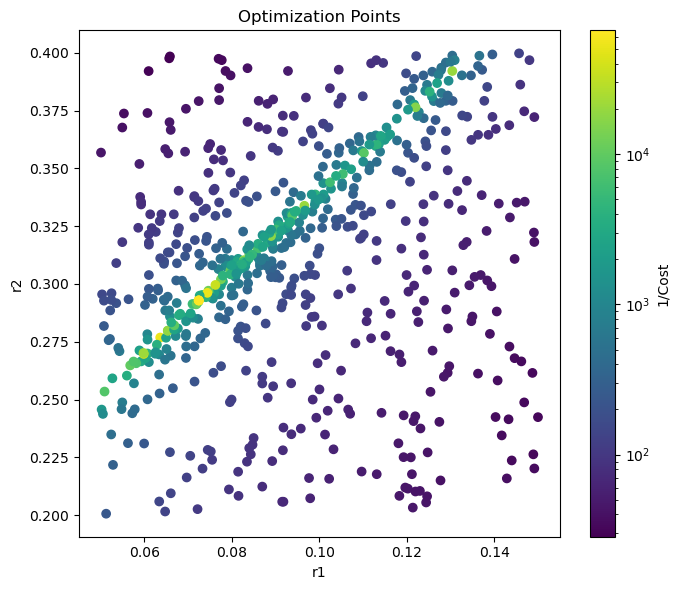

In [9]:
log_file_path_opt = optimizer.log_file
print("Log file path:", log_file_path_opt)
optimizer.plot_optimization_points( log_file_path=log_file_path_opt, use_logscale=True, levels = 100, points_only=True, plot_inverse_cost=True, custom_title="Optimization Points")  

## Analysis

### Find line in parameter space

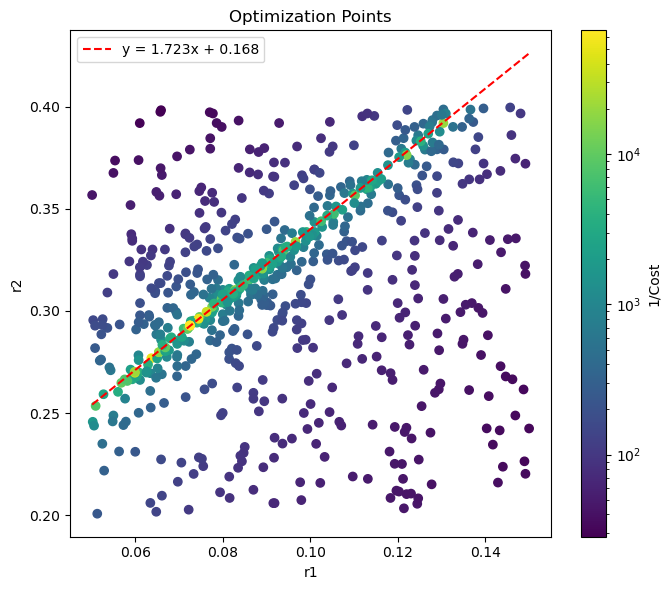

In [10]:
from sources.optimization_data_analyzer import OptimizationDataAnalyzer 
log_file = log_file_path_opt    
analyzer = OptimizationDataAnalyzer(log_file)

# Load all data
analyzer.load_data(debug=True)

# Plot raw data as a scatter with 1/cost
analyzer.plot_raw_data(
    use_logscale=True,
    levels=100,
    points_only=True,
    plot_inverse_cost=True,
    custom_title="Optimization Points"
)

# Overlay the fitted line on the scatter plot
analyzer.plot_fitted_line()



###  Dirac frequency along fitted line

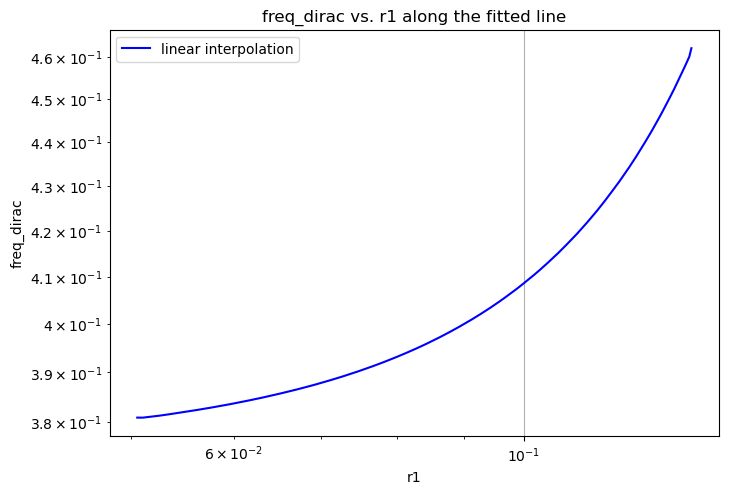

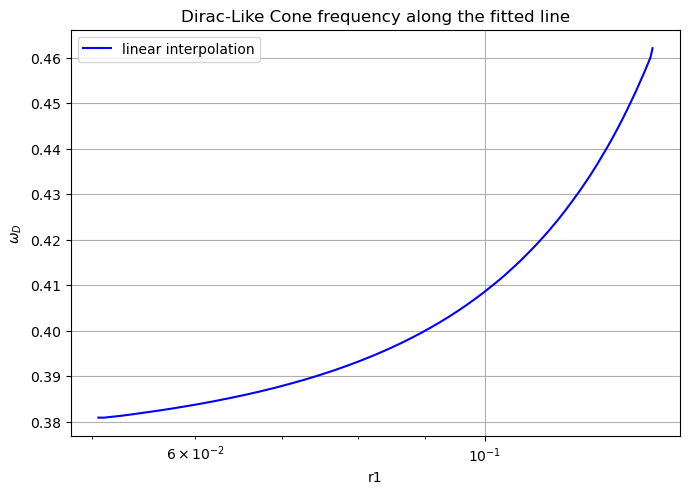

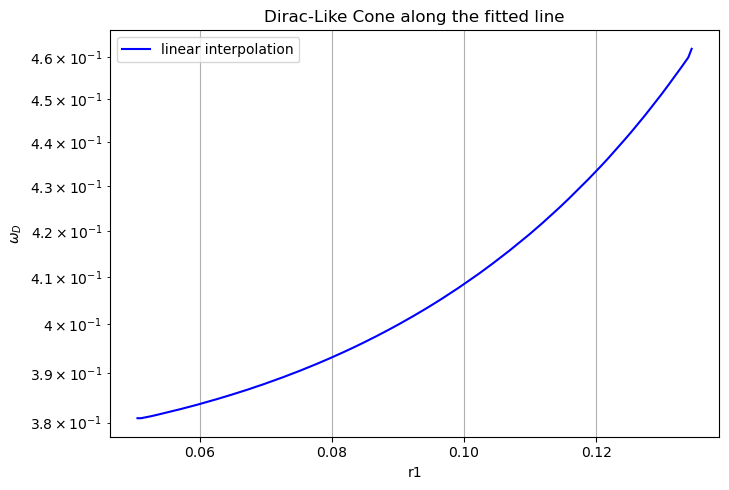

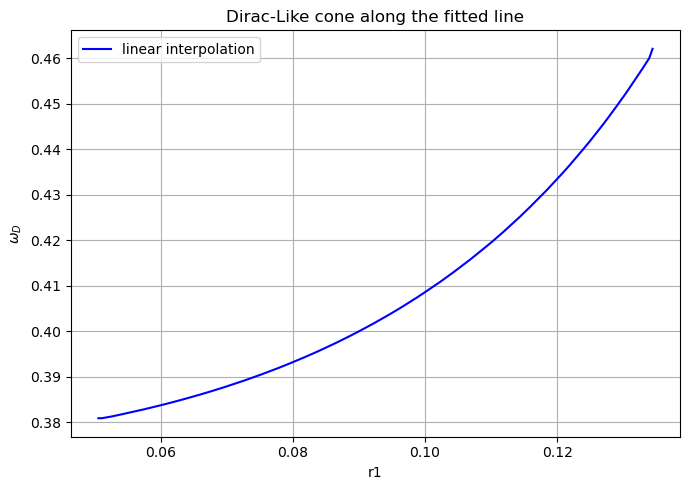

In [ ]:

# Now compute freq_dirac along the fitted line
# and plot freq_dirac vs. param1.
analyzer.plot_freq_dirac_vs_param1_along_fit(
    n_points=200,
    interp_method='linear',
    custom_title="freq_dirac vs. r1 along the fitted line"
)
plt.xscale("log")
plt.yscale("log")
plt.show()

# Now compute freq_dirac along the fitted line
# and plot freq_dirac vs. param1.
analyzer.plot_freq_dirac_vs_param1_along_fit(
    n_points=200,
    interp_method='linear',
    custom_title="Dirac-Like Cone frequency along the fitted line"
)
plt.xscale("log")
plt.ylabel("$\\omega_D$")
plt.xlabel("r1")
plt.show()

# Now compute freq_dirac along the fitted line
# and plot freq_dirac vs. param1.
analyzer.plot_freq_dirac_vs_param1_along_fit(
    n_points=200,
    interp_method='linear',
    custom_title="Dirac-Like Cone frequency along the fitted line"
)
plt.yscale("log")
plt.ylabel("$\\omega_D$")
plt.xlabel("r1")
plt.show()


# Now compute freq_dirac along the fitted line
# and plot freq_dirac vs. param1.
analyzer.plot_freq_dirac_vs_param1_along_fit(
    n_points=200,
    interp_method='linear',
    custom_title="Dirac-Like Cone frequency along the fitted line"
)
plt.ylabel("$\\omega_D$")
plt.xlabel("r1")
plt.show()







# Optimized Crystal

r1: 0.1 r2: 0.3401120414972715


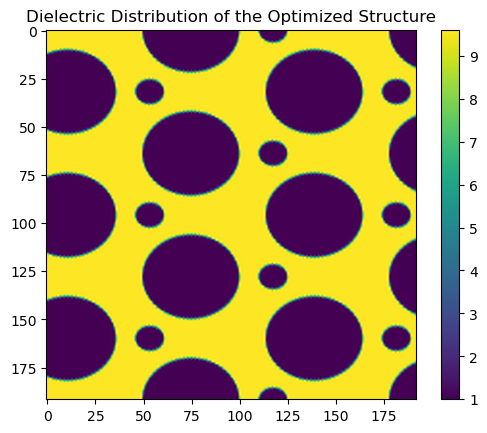

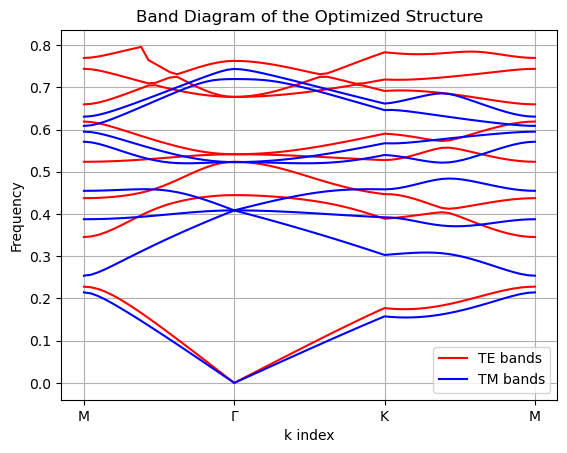

In [19]:
r1 = 0.1
r2 = analyzer.predict_second_parameter(r1)
print("r1:", r1, "r2:", r2)
sim_single_opt = Simulation(simulation_name=name + "_optimized",
                 script=script_single,
                 log_level = Simulation.WARNING)
sim_single_opt.run_hpc(mpb_command_line_params={"r1":r1, "r2":r2})
viewer = SimulationViewer(sim_single_opt)
viewer.plot_epsilon_2d(conversion_options={"rectify": True, "periods": 3})
plt.title("Dielectric Distribution of the Optimized Structure")
viewer.show()
viewer.newfig()
viewer.plot_band_diagram("te", colors = "red", k_points_path=k_points)
viewer.plot_band_diagram("tm", colors = "blue", k_points_path=k_points)
plt.title("Band Diagram of the Optimized Structure")
viewer.show()

In [23]:
k_points

{'k_points_values': [Vector3<0.5, 0.0, 0.0>,
  Vector3<0.0, 0.0, 0.0>,
  Vector3<0.3333333333333333, 0.3333333333333333, 0.0>,
  Vector3<0.5, 0.0, 0.0>],
 'k_points_labels': ['M', 'Γ', 'K', 'M']}

In [32]:
k_point_G_cartesian = mp.Vector3(0.0, 0.0, 0.0)
k_point_X_cartesian = mp.Vector3(0.5, 0.0, 0.0)
k_point_G_reciprocal = lattice.cartesian_to_reciprocal(k_point_G_cartesian)
k_point_X_reciprocal = lattice.cartesian_to_reciprocal(k_point_X_cartesian)
k_points_path_along_x = {
    "k_points_values": [k_point_G_reciprocal, k_point_X_reciprocal],
    "k_points_labels": ["G", "K_X"]
}
print(k_points_path_along_x)


{'k_points_values': [Vector3<0.0, 0.0, 0.0>, Vector3<0.5, 0.25000000000000006, 0.0>], 'k_points_labels': ['G', 'K_X']}


In [33]:
configuration_options_along_x = dict(
    resolution=64,
    num_bands=8,
    k_points=k_points_path_along_x["k_points_values"],
    k_point_interpolation_factor=20, 
    extra_runner_command = "fix-efield-phase output-nonbloch-efield-z output-nonbloch-hfield-y"
)

mpb_config_along_x = MPBSchemeConfigurator(photonic_crystal, ["te", "tm"], **configuration_options_along_x)
script_optimal_along_x= mpb_config_along_x.get_scheme_config(join_newline=True)
print(script_optimal_along_x)



COMMANDS ['(define-param r1 0.3)', '(define-param r2 0.2)']
(set! num-bands 8)
(set! resolution 64)
(set! k-points (list (vector3 0.0 0.0 0.0) (vector3 0.5 0.25000000000000006 0.0)))
(set! k-points (interpolate 20 k-points))
(define-param r1 0.3)
(define-param r2 0.2)
(set! geometry-lattice (make lattice (size 1 1 no-size) (basis1  (vector3 1.0 0.0 0.0)) (basis2  (vector3 0.5000000000000001 0.8660254037844388 0.0)) ))
(set! geometry (list 
 (make block (center (vector3 0.0 0.0 0.0))
  (size (vector3 1e+20 1e+20 1e+20))
  (material (make dielectric (epsilon 9.61))))
 (make cylinder (center (vector3 0.3333333333333333 0.3333333333333333 0.0))
  (radius r1)
  (height 1e+20)
  (material (make dielectric (epsilon 1))))
 (make cylinder (center (vector3 0.6666666666666666 0.6666666666666666 0.0))
  (radius r2)
  (height 1e+20)
  (material (make dielectric (epsilon 1))))
))


(define (output-nonbloch-efield which-band)
    (get-efield which-band)
    (cvector-field-nonbloch! cur-field)
    (ou

r1: 0.1 r2: 0.3401120414972715


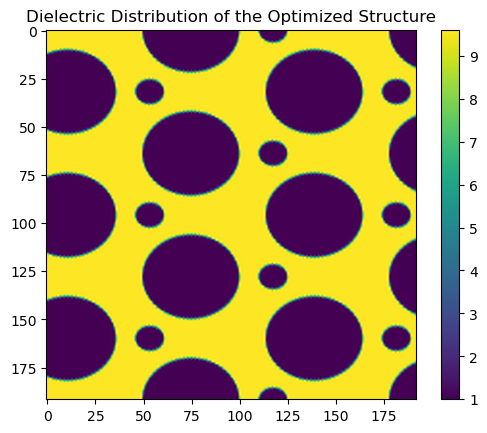

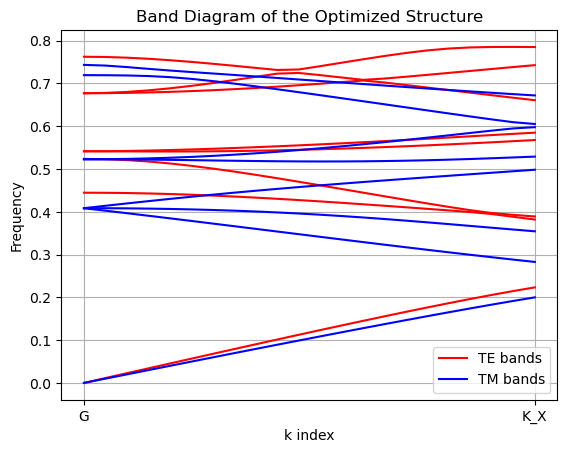

In [35]:
r1 = 0.1
r2 = analyzer.predict_second_parameter(r1)
print("r1:", r1, "r2:", r2)
sim_opt_along_x = Simulation(simulation_name=name + "_opt_along_x",
                 script=script_optimal_along_x,
                 log_level = Simulation.WARNING)
sim_opt_along_x.run_hpc(mpb_command_line_params={"r1":r1, "r2":r2})
viewer = SimulationViewer(sim_opt_along_x)
viewer.plot_epsilon_2d(conversion_options={"rectify": True, "periods": 3})
plt.title("Dielectric Distribution of the Optimized Structure")
viewer.show()
viewer.newfig()
viewer.plot_band_diagram("te", colors = "red", k_points_path=k_points_path_along_x)
viewer.plot_band_diagram("tm", colors = "blue", k_points_path=k_points_path_along_x)
plt.title("Band Diagram of the Optimized Structure")
viewer.show()

/zhome/2f/7/202918/phc_nzi/sources/field_analyzer.py:125: RuntimeWarning: invalid value encountered in scalar divide
  return np.emath.sqrt(eps/mu)


K-Index: 1, Band: 2, Eps: 0j, Mu: 0j, Impedance: (nan+nanj), N_eff: 0j
K-Index: 1, Band: 4, Eps: 0.0, Mu: 0.0, Impedance: nan, N_eff: 0.0
K-Index: 2, Band: 2, Eps: 0.19044328154279475, Mu: 0.004464268706140719, Impedance: 6.531420794178844, N_eff: 0.029158017458089377
K-Index: 2, Band: 4, Eps: (-0.19807525211503718+0j), Mu: (-0.004002411374593243+0j), Impedance: (7.0348403615263875-0j), N_eff: (-0.028156325081420856+0j)
K-Index: 3, Band: 2, Eps: 0.2503129491284657, Mu: 0.01993242284922185, Impedance: 3.5437380571563284, N_eff: 0.07063528542211983
K-Index: 3, Band: 4, Eps: (-0.39276801386693444+0j), Mu: (-0.011046595553583907+0j), Impedance: (5.962849245327191-0j), N_eff: (-0.06586918396012251+0j)
K-Index: 4, Band: 2, Eps: 0.3748048695849185, Mu: 0.03809876911252268, Impedance: 3.136513347101175, N_eff: 0.11949729782955337
K-Index: 4, Band: 4, Eps: (-0.5843640143593156+0j), Mu: (-0.01982047112879057+0j), Impedance: (5.429811403153225-0j), N_eff: (-0.10762142015097634+0j)
K-Index: 5, Ban

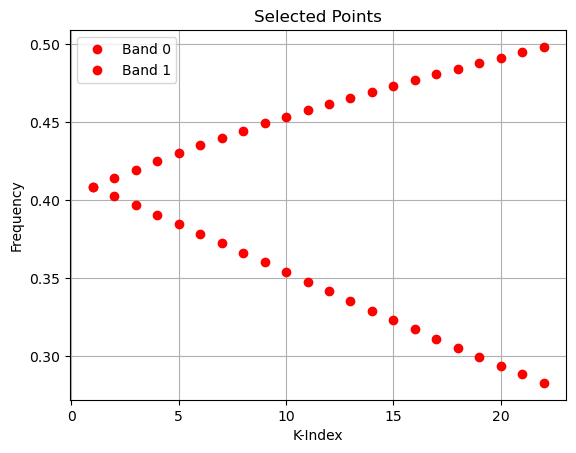

In [37]:
from sources.field_analyzer import FieldAnalyzer

field_analyzer = FieldAnalyzer(sim_opt_along_x, [2,4], "tm")
result_ds = field_analyzer.get_eps_mu_impedance_neff("z", "y", "2D", True, 3, True)


/zhome/2f/7/202918/miniconda3/envs/nzi-mp/lib/python3.11/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/zhome/2f/7/202918/miniconda3/envs/nzi-mp/lib/python3.11/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


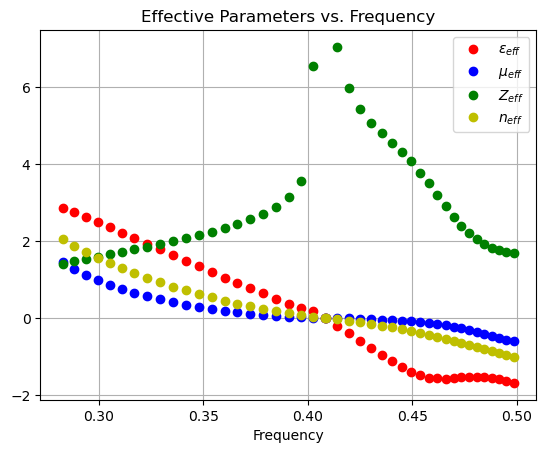

In [42]:
plt.figure()
field_analyzer.plot_eps_vs_freqs()
field_analyzer.plot_mu_vs_freqs()
field_analyzer.plot_impedance_vs_freqs()
field_analyzer.plot_neff_vs_freqs()
plt.title("Effective Parameters vs. Frequency")
plt.show()
